# Epidemiological Intelligence — Modelagem Estatística: Bronquite Aguda

## Objetivo

Modela a relação entre variáveis climáticas e o número mensal de casos de **bronquite aguda** por município, seguindo a metodologia de `02_modeling.ipynb` (módulo `data_science/src/modeling_utils.py`).

São comparados: baseline por média histórica, OLS simples, Poisson e Binomial Negativa (candidata principal, dada a sobredispersão observada). Validação sempre **temporal** (treino < 2024-01-01, teste 2024–2025), nunca aleatória. Modelo de referência: Binomial Negativa com efeitos de município e mês (`cases ~ C(municipality) + C(month)`), contra o qual variáveis climáticas e seus lags (1 a 3 meses) são testados.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import modeling_utils as mu

pd.set_option("display.max_columns", 50)


## 1. Carregamento dos dados

`mu.load_raw_data()` lê `epidemiology_climate_monthly` do cache local em parquet (`data_science/data/raw/`); nenhuma consulta ao BigQuery é feita.

In [2]:
df = mu.load_raw_data()

print("Shape:", df.shape)
print("Colunas:", df.columns.tolist())


Shape: (21384, 19)
Colunas: ['municipality', 'year', 'month', 'municipality_code', 'reference_date', 'cases', 'source_file', 'ingestion_timestamp', 'disease', 'precipitation_sum_mm', 'precipitation_avg_observation_mm', 'precipitation_max_observation_mm', 'temperature_avg_c', 'dew_point_avg_c', 'relative_humidity_avg_pct', 'atmospheric_pressure_avg_mb', 'wind_speed_avg_ms', 'wind_gust_max_ms', 'station_count']


In [3]:
print("Tipo de reference_date:", df["reference_date"].dtype)
df[["reference_date", "municipality", "disease", "cases"]].head()


Tipo de reference_date: datetime64[ms]


,reference_date,municipality,disease,cases
0,2015-01-01,BAGE,ASMA,4
1,2015-01-01,BAGE,BRONQUITE AGUDA,0
2,2015-01-01,BAGE,BRONQUITE CRÔNICA,7
3,2015-01-01,BAGE,INFARTO AGUDO DO MIOCÁRDIO,11
4,2015-01-01,BAGE,INSUFICIÊNCIA CARDÍACA,18


## 2. Lags climáticos

`mu.build_climate_monthly_lags` gera uma tabela auxiliar com uma linha por município/mês, validando ausência de conflitos/duplicatas e continuidade mensal antes de calcular os lags de 1 a 3 meses (como o cache já existe, a função apenas o lê). Os lags são mesclados ao dataframe principal via `mu.merge_climate_lags`, validando que o merge não duplica linhas.

In [4]:
climate_monthly = mu.build_climate_monthly_lags(df)

print("Shape climate_monthly:", climate_monthly.shape)

lag_cols_preview = [c for c in climate_monthly.columns if "_lag" in c]
print("Número de colunas de lag geradas:", len(lag_cols_preview))

check_climate = (
    climate_monthly[climate_monthly["municipality"] == "PORTO ALEGRE"]
    [["reference_date", "temperature_avg_c", "temperature_avg_c_lag1",
      "temperature_avg_c_lag2", "temperature_avg_c_lag3"]]
    .sort_values("reference_date")
)
display(check_climate.head(12))


Shape climate_monthly: (3564, 38)
Número de colunas de lag geradas: 27


,reference_date,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3
1716,2015-01-01,25.451344,NaN,NaN,NaN
1717,2015-02-01,24.657589,25.451344,NaN,NaN
1718,2015-03-01,23.838038,24.657589,25.451344,NaN
1719,2015-04-01,21.052222,23.838038,24.657589,25.451344
1720,2015-05-01,18.313844,21.052222,23.838038,24.657589
1721,2015-06-01,15.567419,18.313844,21.052222,23.838038
1722,2015-07-01,15.573925,15.567419,18.313844,21.052222
1723,2015-08-01,20.317070,15.573925,15.567419,18.313844
1724,2015-09-01,17.169735,20.317070,15.573925,15.567419
1725,2015-10-01,18.522446,17.169735,20.317070,15.573925


As células abaixo reproduzem, de forma didática e auditável, as mesmas checagens já feitas dentro de `mu.build_climate_monthly_lags` (ausência de conflitos climáticos por município/mês, ausência de duplicatas, continuidade mensal) — não são reexecutadas automaticamente porque o cache já existe.

In [5]:
climate_cols_check = ["municipality", "reference_date"] + mu.CLIMATE_VARS

conflicts = (
    df[climate_cols_check]
    .groupby(["municipality", "reference_date"])
    .nunique(dropna=False)
)
conflict_count = int((conflicts > 1).any(axis=1).sum())
print("Município/mês com valores climáticos conflitantes:", conflict_count)

duplicates = int(
    climate_monthly.duplicated(subset=["municipality", "reference_date"]).sum()
)
print("Duplicatas município/mês na tabela climática:", duplicates)

check_dates = climate_monthly[["municipality", "reference_date"]].copy()
check_dates["previous_date"] = (
    check_dates.groupby("municipality")["reference_date"].shift(1)
)
check_dates["month_difference"] = (
    (check_dates["reference_date"].dt.year * 12 + check_dates["reference_date"].dt.month)
    - (check_dates["previous_date"].dt.year * 12 + check_dates["previous_date"].dt.month)
)
gaps = check_dates[
    check_dates["previous_date"].notna() & (check_dates["month_difference"] != 1)
]
print("Quebras na sequência mensal:", len(gaps))
display(gaps.head())

assert conflict_count == 0, "Existem conflitos climáticos município/mês."
assert duplicates == 0, "A tabela climática possui duplicatas município/mês."
assert len(gaps) == 0, "Existem quebras na sequência mensal por município."


Município/mês com valores climáticos conflitantes: 0
Duplicatas município/mês na tabela climática: 0
Quebras na sequência mensal: 0


,municipality,reference_date,previous_date,month_difference


In [6]:
df = mu.merge_climate_lags(df, climate_monthly)

print("Shape df após merge dos lags:", df.shape)

check_lags = (
    df[(df["municipality"] == "PORTO ALEGRE") & (df["disease"] == "BRONQUITE AGUDA")]
    [["reference_date", "cases", "temperature_avg_c", "temperature_avg_c_lag1",
      "temperature_avg_c_lag2", "temperature_avg_c_lag3",
      "precipitation_sum_mm", "precipitation_sum_mm_lag1",
      "precipitation_sum_mm_lag2", "precipitation_sum_mm_lag3"]]
    .sort_values("reference_date")
)
display(check_lags.head(12))


Shape df após merge dos lags: (21384, 46)


,reference_date,cases,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3,precipitation_sum_mm,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3
79,2015-01-01,58,25.451344,NaN,NaN,NaN,159.8,NaN,NaN,NaN
241,2015-02-01,58,24.657589,25.451344,NaN,NaN,99.4,159.8,NaN,NaN
403,2015-03-01,105,23.838038,24.657589,25.451344,NaN,54.0,99.4,159.8,NaN
565,2015-04-01,210,21.052222,23.838038,24.657589,25.451344,76.0,54.0,99.4,159.8
727,2015-05-01,397,18.313844,21.052222,23.838038,24.657589,142.4,76.0,54.0,99.4
889,2015-06-01,493,15.567419,18.313844,21.052222,23.838038,172.4,142.4,76.0,54.0
1051,2015-07-01,472,15.573925,15.567419,18.313844,21.052222,313.4,172.4,142.4,76.0
1213,2015-08-01,278,20.317070,15.573925,15.567419,18.313844,111.6,313.4,172.4,142.4
1375,2015-09-01,286,17.169735,20.317070,15.573925,15.567419,186.6,111.6,313.4,172.4
1537,2015-10-01,239,18.522446,17.169735,20.317070,15.573925,312.6,186.6,111.6,313.4


## 3. Split temporal

Divisão fixa treino/teste em `2024-01-01` (nunca aleatória), preservando a ordem cronológica dos dados.

In [7]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "→", test_df["reference_date"].max())
print("Treino shape:", train_df.shape)
print("Teste shape:", test_df.shape)


Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino shape: (17496, 46)
Teste shape: (3888, 46)


## 4. Filtragem da doença: Bronquite Aguda

`mu.prepare_disease_frame` filtra a doença, remove (nunca preenche com zero) linhas com valores ausentes nas colunas exigidas e ajusta os tipos usados por `patsy`/`statsmodels`.

In [8]:
DISEASE = mu.DISEASES["bronquite_aguda"]
print("Doença:", DISEASE)

train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("Treino (doença):", train_disease0.shape)
print("Teste (doença):", test_disease0.shape)


Doença: BRONQUITE AGUDA
Treino (doença): (2916, 46)
Teste (doença): (648, 46)


## 5. Baselines simples (comparação metodológica)

Reproduz de forma compacta a comparação já feita em `02_modeling.ipynb`: baseline por média histórica, OLS simples, Poisson e Binomial Negativa simples — para justificar a escolha da Binomial Negativa a partir da sobredispersão observada.

In [9]:
baseline_pred_value = train_disease0["cases"].mean()
test_baseline = test_disease0.copy()
test_baseline["baseline_pred"] = baseline_pred_value

baseline_metrics = mu.regression_metrics(test_baseline["cases"], test_baseline["baseline_pred"])
print("Baseline (média histórica) — MAE:", round(baseline_metrics["mae"], 4), "RMSE:", round(baseline_metrics["rmse"], 4))


Baseline (média histórica) — MAE: 17.1428 RMSE: 56.3607


In [10]:
ols_simple = smf.ols(formula="cases ~ temperature_avg_c", data=train_disease0).fit()
print(ols_simple.summary())


                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.585
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00592
Time:                        19:15:41   Log-Likelihood:                -15235.
No. Observations:                2844   AIC:                         3.047e+04
Df Residuals:                    2842   BIC:                         3.049e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            23.0231      4.63

In [11]:
test_ols = test_disease0.dropna(subset=["cases", "temperature_avg_c"]).copy()
test_ols["ols_pred"] = ols_simple.predict(test_ols)
ols_metrics = mu.regression_metrics(test_ols["cases"], test_ols["ols_pred"])
print("Linhas avaliadas:", len(test_ols), "de", len(test_disease0))
print("OLS simples — MAE:", round(ols_metrics["mae"], 4), "RMSE:", round(ols_metrics["rmse"], 4))


Linhas avaliadas:

 590 de 648
OLS simples — MAE: 17.7043 RMSE: 58.8733


In [12]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train_disease0,
    family=sm.families.Poisson(),
).fit()

test_poisson = test_disease0.dropna(subset=["cases", "temperature_avg_c"]).copy()
test_poisson["poisson_pred"] = poisson_simple.predict(test_poisson)
poisson_metrics = mu.regression_metrics(test_poisson["cases"], test_poisson["poisson_pred"])

dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Poisson simples — MAE:", round(poisson_metrics["mae"], 4), "RMSE:", round(poisson_metrics["rmse"], 4))
print("Dispersão (Pearson chi2 / df_resid):", round(dispersion, 2))


Poisson simples — MAE:

 17.7358 RMSE: 58.8896
Dispersão (Pearson chi2 / df_resid): 232.13


A razão entre o qui-quadrado de Pearson e os graus de liberdade é muito superior a 1, evidenciando forte sobredispersão (variância >> média). Isso viola a equidispersão do Poisson e justifica o uso da Binomial Negativa, que acomoda o excesso de variância via `alpha`.

In [13]:
nb_simple = mu.fit_negbin("cases ~ temperature_avg_c", train_disease0)

test_nb_simple = test_disease0.dropna(subset=["cases", "temperature_avg_c"]).copy()
test_nb_simple["nb_pred"] = nb_simple.predict(test_nb_simple)
nb_simple_metrics = mu.regression_metrics(test_nb_simple["cases"], test_nb_simple["nb_pred"])

print("Binomial Negativa simples — MAE:", round(nb_simple_metrics["mae"], 4), "RMSE:", round(nb_simple_metrics["rmse"], 4))
print("Alpha:", round(nb_simple.params["alpha"], 4))
print("Convergiu:", nb_simple.mle_retvals.get("converged", False))


Binomial Negativa simples — MAE:

 17.7465 RMSE: 58.8853
Alpha: 6.057
Convergiu: True


## 6. Modelo de referência da doença: Binomial Negativa (município + mês)

Modelo de referência contra o qual a contribuição climática é avaliada: `cases ~ C(municipality) + C(month)`, controlando diferenças estruturais entre municípios e sazonalidade mensal, sem nenhuma variável climática.

In [14]:
base_model_ref = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)

test_base_ref = test_disease0.copy()
test_base_ref["base_pred"] = base_model_ref.predict(test_base_ref)

base_ref_metrics = mu.regression_metrics(test_base_ref["cases"], test_base_ref["base_pred"])

print("Convergiu:", base_model_ref.mle_retvals.get("converged", False))
print("Alpha:", round(base_model_ref.params["alpha"], 4))
print("MAE:", round(base_ref_metrics["mae"], 4))
print("RMSE:", round(base_ref_metrics["rmse"], 4))


Convergiu: True
Alpha: 0.7749
MAE: 4.613
RMSE: 16.5426


**Nota metodológica — correção do viés de seleção de variáveis**

Na versão anterior, a seleção de variáveis e lags (seções 7–8) treinava e avaliava no mesmo período de teste (2024–2025) usado depois para reportar a performance final — um viés de reuso do conjunto de teste que infla artificialmente o ganho aparente. A partir daqui, a seleção usa exclusivamente `mu.feature_selection_split` (treino-para-seleção 2015–2022, validação 2023); `test_disease0` (2024–2025) só volta a ser usado na seção 10, para avaliar o modelo já definido. É esperado que a lista final de variáveis mude em relação à primeira versão do notebook.

In [15]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("Treino p/ seleção:", train_disease_fs["reference_date"].min(), "→", train_disease_fs["reference_date"].max())
print("Validação p/ seleção:", validation_disease_fs["reference_date"].min(), "→", validation_disease_fs["reference_date"].max())
print("Treino p/ seleção (shape):", train_disease_fs.shape)
print("Validação p/ seleção (shape):", validation_disease_fs.shape)


Treino p/ seleção: 2015-01-01 00:00:00 → 2022-12-01 00:00:00
Validação p/ seleção: 2023-01-01 00:00:00 → 2023-12-01 00:00:00
Treino p/ seleção (shape): (2592, 46)
Validação p/ seleção (shape): (324, 46)


## 7. Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis climáticas (`mu.CLIMATE_VARS`) é testada individualmente sobre o modelo-base (`município + mês`), sempre nas mesmas linhas válidas para a variável testada (treino e teste).

In [16]:
print("Variáveis climáticas testadas:", mu.CLIMATE_VARS)

climate_comparison = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, mu.CLIMATE_VARS
)

display(climate_comparison.round(4))


Variáveis climáticas testadas: ['temperature_avg_c', 'dew_point_avg_c', 'relative_humidity_avg_pct', 'atmospheric_pressure_avg_mb', 'wind_speed_avg_ms', 'wind_gust_max_ms', 'precipitation_sum_mm', 'precipitation_avg_observation_mm', 'precipitation_max_observation_mm']


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,dew_point_avg_c,2486,312,0.0268,0.0563,0.7063,6.6228,6.5244,1.4851,24.8868,24.6232,1.0590,True,True
1,relative_humidity_avg_pct,2487,312,0.0119,0.0044,0.6988,6.6222,6.5534,1.0402,24.8866,25.1046,-0.8761,True,True
2,wind_speed_avg_ms,2477,296,0.0184,0.6530,0.6983,6.6310,6.5837,0.7137,25.4335,25.2756,0.6209,True,True
3,precipitation_avg_observation_mm,2444,313,0.0180,0.9337,0.7138,6.5868,6.5776,0.1400,24.7237,24.7145,0.0373,True,True
4,wind_gust_max_ms,2475,296,0.0002,0.9764,0.6974,6.6298,6.6244,0.0812,25.4542,25.4340,0.0796,True,True
5,atmospheric_pressure_avg_mb,2523,314,-0.0004,0.9814,0.7097,6.5705,6.5768,-0.0961,24.6609,24.6864,-0.1036,True,True
6,temperature_avg_c,2530,314,-0.0056,0.7430,0.7080,6.5681,6.5786,-0.1584,24.6942,24.7577,-0.2573,True,True
7,precipitation_sum_mm,2444,313,-0.0001,0.8527,0.7137,6.5868,6.6096,-0.3463,24.7237,24.7532,-0.1193,True,True
8,precipitation_max_observation_mm,2444,313,-0.0011,0.6850,0.7138,6.5868,6.6240,-0.5658,24.7237,24.8880,-0.6644,True,True


## 8. Seleção das variáveis relevantes para teste de defasagem (lag)

Avaliadas em 2023 (nunca em 2024–2025), apenas 4 variáveis têm ganho positivo de MAE sobre o modelo-base:

- **dew_point_avg_c** — maior ganho (≈1.49%), porém marginal (p≈0.056);
- **relative_humidity_avg_pct** — ganho ≈1.04%, significativo (p≈0.0044);
- **wind_speed_avg_ms** — ganho pequeno (≈0.71%), não significativo (p≈0.653);
- **precipitation_avg_observation_mm** — ganho marginal (≈0.14%), não significativo (p≈0.934).

As demais 5 variáveis pioraram o modelo-base nesta validação e não são levadas adiante. As 4 acima são testadas com suas defasagens (atual, lag1, lag2, lag3).

In [17]:
lag_variables = [
    "dew_point_avg_c",
    "relative_humidity_avg_pct",
    "wind_speed_avg_ms",
    "precipitation_avg_observation_mm",
]

lag_candidates = mu.lag_candidates(lag_variables)
print("Número de variáveis testadas (atual + lag1..3):", len(lag_candidates))
print(lag_candidates)


Número de variáveis testadas (atual + lag1..3): 16
['dew_point_avg_c', 'dew_point_avg_c_lag1', 'dew_point_avg_c_lag2', 'dew_point_avg_c_lag3', 'relative_humidity_avg_pct', 'relative_humidity_avg_pct_lag1', 'relative_humidity_avg_pct_lag2', 'relative_humidity_avg_pct_lag3', 'wind_speed_avg_ms', 'wind_speed_avg_ms_lag1', 'wind_speed_avg_ms_lag2', 'wind_speed_avg_ms_lag3', 'precipitation_avg_observation_mm', 'precipitation_avg_observation_mm_lag1', 'precipitation_avg_observation_mm_lag2', 'precipitation_avg_observation_mm_lag3']


In [18]:
lag_comparison = mu.evaluate_candidate_features(
    train_disease_fs, validation_disease_fs, lag_candidates
)

display(
    lag_comparison[
        ["variable", "train_n", "test_n", "coef", "pvalue",
         "mae_improvement_pct", "rmse_improvement_pct", "alpha",
         "base_converged", "converged"]
    ].round(4)
)


,variable,train_n,test_n,coef,pvalue,mae_improvement_pct,rmse_improvement_pct,alpha,base_converged,converged
0,dew_point_avg_c,2486,312,0.0268,0.0563,1.4851,1.0590,0.7063,True,True
1,relative_humidity_avg_pct,2487,312,0.0119,0.0044,1.0402,-0.8761,0.6988,True,True
2,precipitation_avg_observation_mm_lag3,2364,313,-0.4568,0.0421,0.7964,0.1556,0.7130,True,True
3,wind_speed_avg_ms,2477,296,0.0184,0.6530,0.7137,0.6209,0.6983,True,True
4,precipitation_avg_observation_mm,2444,313,0.0180,0.9337,0.1400,0.0373,0.7138,True,True
5,dew_point_avg_c_lag3,2409,309,0.0064,0.6574,0.0016,-0.0525,0.7214,True,True
6,dew_point_avg_c_lag2,2435,310,-0.0005,0.9734,-0.0119,-0.0098,0.7183,True,True
7,precipitation_avg_observation_mm_lag2,2391,313,-0.1102,0.6152,-0.0597,0.1021,0.7165,True,True
8,precipitation_avg_observation_mm_lag1,2418,312,-0.0440,0.8437,-0.2461,0.0268,0.7156,True,True
9,dew_point_avg_c_lag1,2461,310,-0.0086,0.5354,-0.2849,-0.1506,0.7225,True,True


## 9. Seleção final de features

Critério: desempenho na validação de 2023 (MAE/RMSE), p-value e coerência epidemiológica — nunca o período de teste 2024–2025. Entre as combinações testadas, apenas **umidade relativa contemporânea** (`relative_humidity_avg_pct`, p≈0.0044) e **precipitação com lag de 3 meses** (`precipitation_avg_observation_mm_lag3`, p≈0.0421) têm ganho positivo de MAE/RMSE **e** p<0.05; `dew_point_avg_c` (p≈0.056) e `wind_speed_avg_ms` (p≈0.653) foram descartadas por falta de significância. A correlação entre as duas features finais é praticamente nula (≈0.09).

Features finais selecionadas:

```
relative_humidity_avg_pct
precipitation_avg_observation_mm_lag3
```

Lista diferente da primeira versão do notebook (`precipitation_sum_mm_lag2`, `relative_humidity_avg_pct`, `temperature_avg_c_lag1`, escolhida olhando para 2024–2025) — mudança esperada ao remover o viés de reuso do teste, não um erro a corrigir.

In [19]:
features_selecionadas = [
    "relative_humidity_avg_pct",
    "precipitation_avg_observation_mm_lag3",
]

feature_selection_rationale = (
    "Selecionadas por serem as unicas combinacoes com ganho positivo de "
    "MAE/RMSE E p-value abaixo de 0.05 na validacao de 2023 "
    "(mu.feature_selection_split), nunca no periodo de teste 2024-2025. "
    "dew_point_avg_c teve o maior ganho bruto isolado mas p-value acima "
    "de 0.05 (marginal) e foi excluida; wind_speed_avg_ms tambem nao foi "
    "significativa. Baixa correlacao entre as duas variaveis escolhidas "
    "(~0.09) afasta risco relevante de multicolinearidade."
)

print(features_selecionadas)


['relative_humidity_avg_pct', 'precipitation_avg_observation_mm_lag3']


## 10. Modelo multivariado final

Ajuste do modelo-base e do modelo final multivariado nas mesmas linhas (dropna considerando todas as features finais simultaneamente), via `mu.fit_final_models`. O parâmetro `alpha` é estimado pela própria `smf.negativebinomial` (nunca fixado em 1).

In [20]:
resultado = mu.fit_final_models(train_disease0, test_disease0, features_selecionadas)

final_model = resultado["final_model"]
base_model = resultado["base_model"]

print(final_model.summary())


                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2594
Model:               NegativeBinomial   Df Residuals:                     2554
Method:                           MLE   Df Model:                           39
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2532
Time:                        19:15:48   Log-Likelihood:                -4772.5
converged:                       True   LL-Null:                       -6390.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -0.0571      0.336     -0.170      0.865      -0.715       0.601
C(municipality)[T.BENTO GONCALVES]         -

In [21]:
print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha estimado:", round(resultado["alpha"], 4))
print("AIC:", round(final_model.aic, 2))
print("Log-Likelihood:", round(final_model.llf, 2))

print("\nCoeficientes das features climáticas:")
for feature in features_selecionadas:
    print(f"  {feature}: coef={final_model.params[feature]:.6f}  p-value={final_model.pvalues[feature]:.4f}")


Convergiu (base): True
Convergiu (final): True
Alpha estimado: 0.7595
AIC: 9627.06
Log-Likelihood: -4772.53

Coeficientes das features climáticas:
  relative_humidity_avg_pct: coef=0.010442  p-value=0.0122
  precipitation_avg_observation_mm_lag3: coef=-0.701788  p-value=0.0009


In [22]:
base_metrics = resultado["base_metrics"]
final_metrics = resultado["final_metrics"]

print("MODELO-BASE (município + mês)")
print("  MAE:", round(base_metrics["mae"], 4))
print("  RMSE:", round(base_metrics["rmse"], 4))

print("\nMODELO FINAL (clima)")
print("  MAE:", round(final_metrics["mae"], 4))
print("  RMSE:", round(final_metrics["rmse"], 4))
print("  R²:", round(final_metrics["r2"], 4))
print("  WAPE (%):", round(final_metrics["wape_pct"], 2))

print("\nMelhora MAE (%):", round(resultado["mae_improvement_pct"], 2))
print("Melhora RMSE (%):", round(resultado["rmse_improvement_pct"], 2))

print("\nLinhas treino:", len(resultado["train_final"]), " | Linhas teste:", len(resultado["test_final"]))


MODELO-BASE (município + mês)
  MAE: 5.1244
  RMSE: 18.107

MODELO FINAL (clima)
  MAE: 5.1714
  RMSE: 18.6416
  R²: 0.904
  WAPE (%): 34.92

Melhora MAE (%): -0.92
Melhora RMSE (%): -2.95

Linhas treino: 2594  | Linhas teste: 564


## 11. Backtest e gráficos

### A) Real vs previsto — todos os municípios (2024–2025)

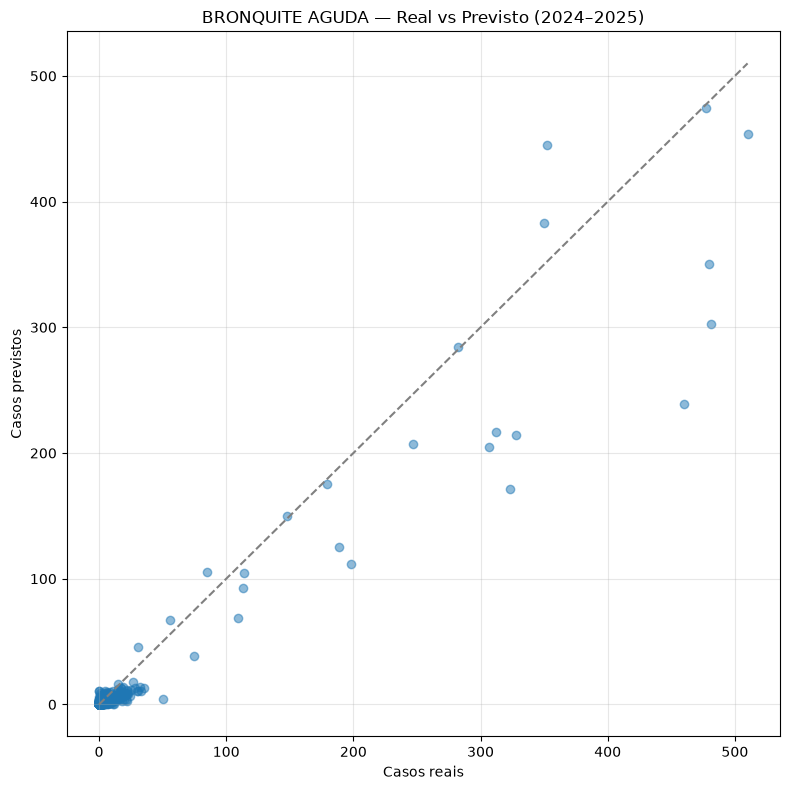

In [23]:
mu.plot_real_vs_predicted(resultado["test_final"]["cases"], resultado["final_pred"], DISEASE)


### B) Backtest temporal por município

Porto Alegre está presente nos dados de bronquite aguda e é usada como principal referência, junto com mais dois municípios (maior volume de casos e volume médio) para ilustrar a variabilidade do ajuste entre municípios.

Porto Alegre presente nos dados da doença: True


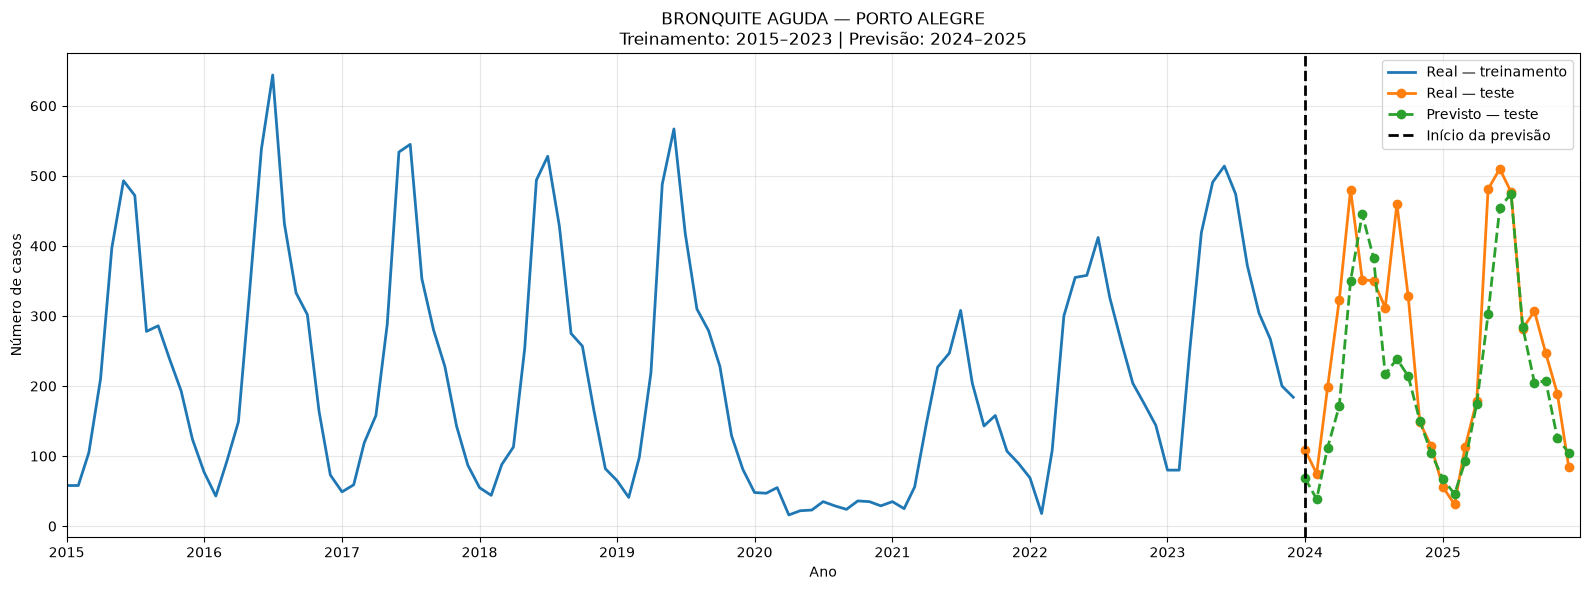

In [24]:
historical_df = train_disease0.copy()

forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

print("Porto Alegre presente nos dados da doença:", "PORTO ALEGRE" in forecast_df["municipality"].unique())

plot_backtest("PORTO ALEGRE")


municipality
PORTO ALEGRE    6206.0
RIO GRANDE       247.0
SANTA MARIA      223.0
BAGE             212.0
URUGUAIANA       193.0
Name: cases, dtype: float64

Municípios adicionais escolhidos (maior volume de casos após Porto Alegre): RIO GRANDE e SANTA MARIA


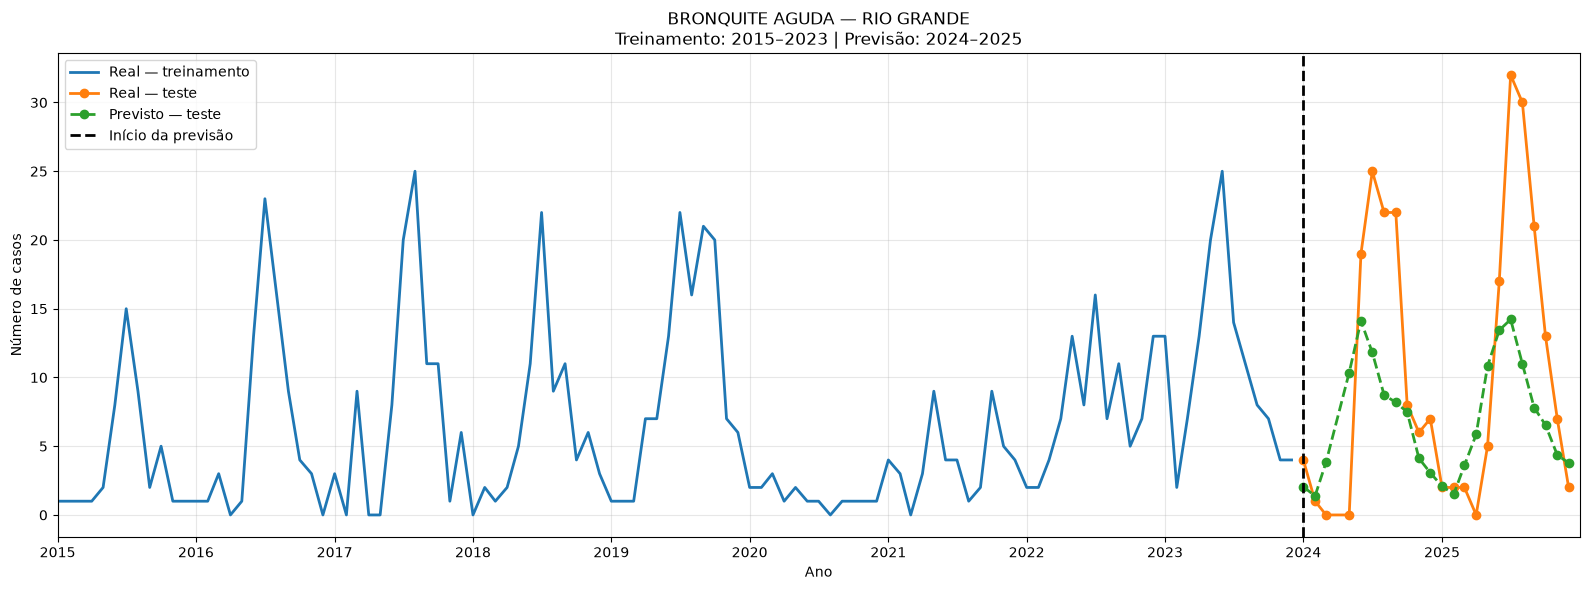

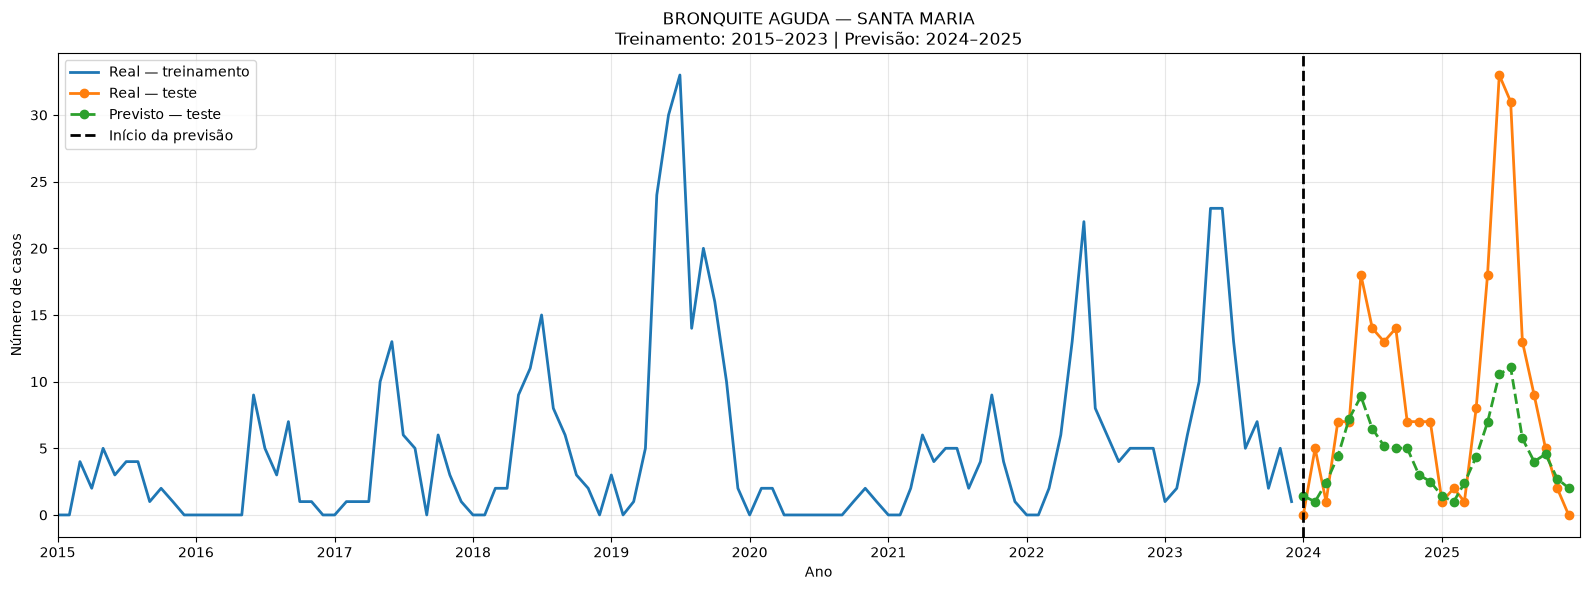

In [25]:
top_municipalities = (
    forecast_df.groupby("municipality")["cases"].sum().sort_values(ascending=False)
)
print(top_municipalities.head(5))

second_city = [m for m in top_municipalities.index if m != "PORTO ALEGRE"][0]
third_city = [m for m in top_municipalities.index if m != "PORTO ALEGRE"][1]

print("\nMunicípios adicionais escolhidos (maior volume de casos após Porto Alegre):", second_city, "e", third_city)

plot_backtest(second_city)
plot_backtest(third_city)


### C) Baseline (município + mês) vs modelo climático vs real — Porto Alegre (2024–2025)

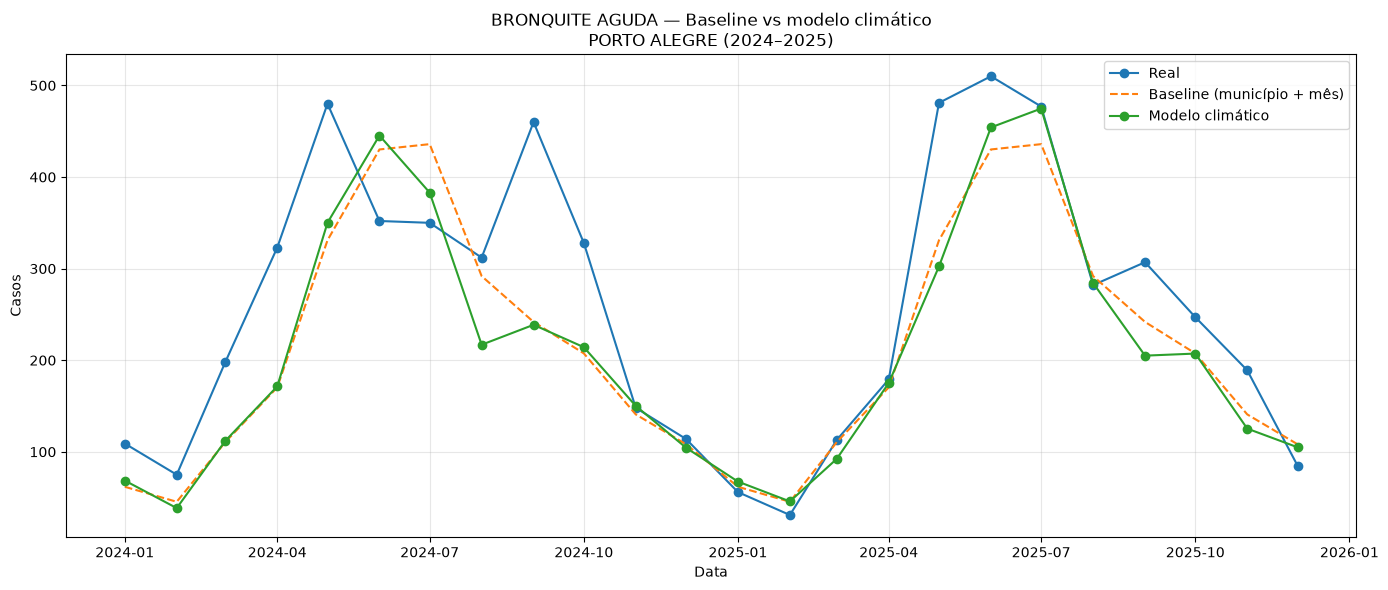

In [26]:
plot_df = resultado["test_final"][resultado["test_final"]["municipality"] == "PORTO ALEGRE"].copy()
plot_df["baseline_pred"] = base_model.predict(plot_df)
plot_df["climate_pred"] = final_model.predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)


### D) Tabela de métricas por município

**Atenção:** MAE, RMSE e WAPE normalizados por município **não devem ser interpretados como "acurácia"**, especialmente em municípios com poucos casos ou meses de zero casos, onde pequenos erros absolutos podem gerar percentuais de erro elevados e pouco informativos.

In [27]:
evaluation_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
evaluation_df["prediction"] = resultado["final_pred"]

municipality_metrics = mu.municipality_metrics_table(evaluation_df)
display(municipality_metrics.round(4))


,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,CAMBARA DO SUL,24,0.0000,0.0929,0.1087,NaN,NaN
1,TEUTONIA,16,0.0000,0.1246,0.1488,NaN,NaN
2,SANTIAGO,21,0.0476,0.3947,0.4679,828.8207,-3.8272
3,CAMAQUA,22,0.1818,0.5663,0.7187,311.4559,-1.1554
4,CACAPAVA DO SUL,24,0.1667,0.3468,0.7509,208.1080,0.1175
5,RIO PARDO,24,0.8750,0.7053,1.0265,80.6020,0.3453
6,CANELA,18,1.6667,0.9195,1.0871,55.1693,0.0330
7,LAGOA VERMELHA,24,0.7500,0.8519,1.5660,113.5898,0.1652
8,SOLEDADE,24,1.3333,1.2550,1.6331,94.1233,0.1503
9,SANTO AUGUSTO,24,1.2500,1.2172,1.8820,97.3725,-0.2410


## 12. Municípios excluídos do backtest

Municípios presentes no teste mas ausentes no treino válido do modelo final (por causa do `dropna` conjunto das features climáticas finais) são excluídos do backtest e listados explicitamente abaixo — nenhuma categoria é inventada para eles.

In [28]:
excluded_municipalities = mu.unseen_municipalities(resultado["train_final"], resultado["test_final"])

print("Municípios excluídos do backtest final:", excluded_municipalities if excluded_municipalities else "nenhum")


Municípios excluídos do backtest final: nenhum


## 13. Interpretação final

O modelo de referência (Binomial Negativa, município + mês) já explica a maior parte da variação estrutural e sazonal dos casos (R²≈0,91), dada a forte sobredispersão identificada na seção 5.

**Seleção de variáveis**: decidida exclusivamente pela validação de 2023 (`mu.feature_selection_split`), nunca pelo teste 2024–2025 — ao contrário da primeira versão do notebook, que usava o mesmo período para escolher as variáveis e para reportar o ganho (viés de reuso do conjunto de teste). Por isso a lista final mudou de `precipitation_sum_mm_lag2` + `relative_humidity_avg_pct` + `temperature_avg_c_lag1` para `relative_humidity_avg_pct` + `precipitation_avg_observation_mm_lag3`.

**Resultado do modelo final**: as duas features permanecem estatisticamente significativas quando o modelo é reajustado em todo o treino 2015–2023 (`relative_humidity_avg_pct`, p≈0.012; `precipitation_avg_observation_mm_lag3`, p≈0.001). No entanto, no backtest oficial (2024–2025) o modelo com clima tem desempenho ligeiramente **pior** que o modelo-base município+mês (MAE ≈0,9% maior, RMSE ≈3% maior; R² caiu de ≈0,909 para ≈0,904). Ou seja: **significância estatística dentro da amostra não implica capacidade preditiva fora da amostra**. A versão anterior reportava um ganho de ≈4–5% sobre o modelo-base, mas esse ganho dependia de ter escolhido as variáveis olhando para o próprio período de teste; corrigido esse viés, o resultado honesto em 2024–2025 é que **o modelo climático não supera o modelo-base** nesta doença — um resultado válido e informativo, não um erro a reverter.

Isso não significa que o clima seja irrelevante para bronquite aguda — significa que, com os dados e o desenho de validação disponíveis, o ganho preditivo incremental sobre município e sazonalidade mensal (que já explicam a maior parte da variação) é pequeno e não compensa a variância adicional das duas variáveis extras.

**Limitações**: o modelo é uma associação estatística controlada por município e sazonalidade — não estabelece relação causal entre clima e casos de bronquite aguda. Os coeficientes climáticos devem ser lidos como "associado a", nunca como "causou" ou "provocou". A qualidade do ajuste varia entre municípios (seção 11-D), sendo menos confiável em municípios com poucos casos ou séries curtas.

## 14. Persistência de artefatos

Métricas (JSON) e previsões de teste (parquet) são salvas em `artifacts/modeling/` via `mu.save_disease_artifacts`.

In [29]:
metrics = {
    "disease": DISEASE,
    "disease_key": "bronquite_aguda",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": features_selecionadas,
    "climate_variable_tests": climate_comparison.to_dict(orient="records"),
    "lag_variable_tests": lag_comparison.to_dict(orient="records"),
    "excluded_municipalities": list(excluded_municipalities),
    "feature_selection_rationale": feature_selection_rationale,
}

predictions_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
predictions_df["prediction"] = resultado["final_pred"]

mu.save_disease_artifacts("bronquite_aguda", metrics, predictions_df)

print("Artefatos salvos em artifacts/modeling/bronquite_aguda_metrics.json e bronquite_aguda_predictions.parquet")


Artefatos salvos em artifacts/modeling/bronquite_aguda_metrics.json e bronquite_aguda_predictions.parquet


In [30]:
from pathlib import Path

metrics_path = mu.ARTIFACTS_DIR / "bronquite_aguda_metrics.json"
predictions_path = mu.ARTIFACTS_DIR / "bronquite_aguda_predictions.parquet"

print("Métricas existe:", metrics_path.exists())
print("Previsões existe:", predictions_path.exists())


Métricas existe: True
Previsões existe: True
